# RCT vs. Selection Bias: Does Random Assignment Matter?

**Question:** Does a get-out-the-vote (GOTV) phone call increase voter turnout?

**Data:** A sample from a large voter mobilization experiment in Iowa. Voters were randomly
assigned to either receive an encouragement-to-vote phone call or not. The dataset includes
whether someone voted in 1998, 2000, and 2002, basic demographics, and treatment status.

**The point of this notebook:** the same underlying data and question, analyzed two ways.

1. **Design A (RCT):** Compare people *randomly assigned* to receive a call vs. not, regardless
   of whether they actually answered.
2. **Design B (Selection bias):** Compare people who *actually answered and listened* to the
   call vs. those who didn't &mdash; which is no longer random, since picking up the phone is a choice.

The goal is to show, side by side, why randomization matters: in Design A the estimated effect
barely moves as we add controls. In Design B the estimate is cut in half once we control for
who tends to pick up the phone in the first place.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:.3f}')

full = pd.read_stata('../data/iowa_sample_full.dta')
sub = pd.read_stata('../data/iowa_sample_treatgroup.dta')

print(f"Full sample (random assignment): {full.shape[0]:,} rows")
print(f"Contacted subsample (actual answer): {sub.shape[0]:,} rows")

Full sample (random assignment): 100,931 rows
Contacted subsample (actual answer): 15,000 rows


## Design A: Randomized Assignment (`treat_real`)

### Balance table

If randomization worked, treatment and control should look statistically identical on pre-treatment characteristics.

In [2]:
def balance_table(data, treat_col, covars):
    rows = []
    t = data[data[treat_col] == 1]
    c = data[data[treat_col] == 0]
    for var in covars:
        mean_t, mean_c = t[var].mean(), c[var].mean()
        tstat, pval = stats.ttest_ind(t[var].dropna(), c[var].dropna(), equal_var=False)
        rows.append({
            'Variable': var,
            'Control Mean': mean_c,
            'Treatment Mean': mean_t,
            'Difference': mean_t - mean_c,
            'P-value': pval
        })
    return pd.DataFrame(rows).set_index('Variable')

covars = ['age', 'female', 'newreg', 'vote98', 'vote00', 'busy']
bal_A = balance_table(full, 'treat_real', covars)
bal_A

,Control Mean,Treatment Mean,Difference,P-value
Variable,,,,
age,55.795,55.782,-0.013,0.939
female,0.563,0.559,-0.004,0.354
newreg,0.048,0.049,0.001,0.575
vote98,0.572,0.574,0.002,0.673
vote00,0.734,0.732,-0.002,0.673
busy,0.000,0.030,0.030,0.000


All differences are small and none are statistically significant at conventional levels
(p > 0.05), except `busy` &mdash; which is mechanical, since only people who were called can have
a busy signal recorded. This is the signature of a working randomization: treatment and control
groups look alike on everything that predicts the outcome.

### Regression: does the effect survive adding controls?

Specification: `vote02 ~ treat_real [+ controls]`, adding one block of controls at a time.

In [3]:
specs_A = [
    'vote02 ~ treat_real',
    'vote02 ~ treat_real + age',
    'vote02 ~ treat_real + age + female + newreg',
    'vote02 ~ treat_real + age + female + newreg + vote00 + vote98',
    'vote02 ~ treat_real + age + female + newreg + vote00 + vote98 + busy',  # 'state' dropped: constant in this sample (all Iowa), causes rank deficiency
]

models_A = [smf.ols(spec, data=full).fit(cov_type='HC1') for spec in specs_A]
coef_A = [m.params['treat_real'] for m in models_A]
se_A = [m.bse['treat_real'] for m in models_A]

summary_A = pd.DataFrame({
    'Model': [f'({i+1})' for i in range(len(models_A))],
    'Controls added': ['None', '+ Age', '+ Gender, New Reg', '+ Prior Turnout', '+ Busy'],
    'Treatment Effect (pp)': [c * 100 for c in coef_A],
    'Std. Error': [s * 100 for s in se_A],
    "R-squared": [m.rsquared for m in models_A],
})
summary_A

,Model,Controls added,Treatment Effect (pp),Std. Error,R-squared
0,(1),None,1.202,0.433,0.000
1,(2),+ Age,1.210,0.422,0.049
2,(3),"+ Gender, New Reg",1.206,0.421,0.066
3,(4),+ Prior Turnout,1.195,0.365,0.304
4,(5),+ Busy,1.243,0.370,0.304


The coefficient stays pinned around **1.2 percentage points** across all five specifications. Adding controls barely moves it at all, exactly what we'd expect when treatment assignment is genuinely random and uncorrelated with the controls.

## Design B: Actual Contact (`contact`)

Same outcome, same-ish population, but now treatment is defined by whether someone *answered
and listened*, not by random assignment. This is a choice, not a coin flip.

### Balance table

In [4]:
bal_B = balance_table(sub, 'contact', covars)
bal_B

,Control Mean,Treatment Mean,Difference,P-value
Variable,,,,
age,53.402,58.570,5.168,0.000
female,0.543,0.577,0.034,0.000
newreg,0.054,0.044,-0.009,0.010
vote98,0.540,0.614,0.075,0.000
vote00,0.697,0.774,0.077,0.000
busy,0.056,0.000,-0.056,0.000


This looks completely different. People who answered are about 5 years older, less likely to
be newly registered, and had meaningfully higher turnout in prior elections &mdash; and every one of
those differences is statistically significant (p ≈ 0). Answering the phone is correlated with
being the kind of person who was already going to vote. Any naive comparison here will conflate
the effect of the call with the fact that "answerers" were already more likely to vote.

### Regression: watch the estimate move as controls are added

In [5]:
specs_B = [
    'vote02 ~ contact',
    'vote02 ~ contact + age',
    'vote02 ~ contact + age + female + newreg',
    'vote02 ~ contact + age + female + newreg + vote00 + vote98',
    'vote02 ~ contact + age + female + newreg + vote00 + vote98 + busy',
]

models_B = [smf.ols(spec, data=sub).fit(cov_type='HC1') for spec in specs_B]
coef_B = [m.params['contact'] for m in models_B]
se_B = [m.bse['contact'] for m in models_B]

summary_B = pd.DataFrame({
    'Model': [f'({i+1})' for i in range(len(models_B))],
    'Controls added': ['None', '+ Age', '+ Gender, New Reg', '+ Prior Turnout', '+ Busy'],
    'Treatment Effect (pp)': [c * 100 for c in coef_B],
    'Std. Error': [s * 100 for s in se_B],
    "R-squared": [m.rsquared for m in models_B],
})
summary_B

,Model,Controls added,Treatment Effect (pp),Std. Error,R-squared
0,(1),None,11.365,0.792,0.013
1,(2),+ Age,8.633,0.789,0.054
2,(3),"+ Gender, New Reg",7.466,0.786,0.071
3,(4),+ Prior Turnout,5.341,0.684,0.299
4,(5),+ Busy,5.392,0.694,0.299


The naive estimate (no controls) says answering the call raises turnout by roughly **11 percentage points** &mdash; implausibly large for a single phone call. Once prior voting history enters the model, the estimate roughly **halves**. That drop is the selection bias being absorbed by the controls, not a real change in the effect of the call itself.

## Side-by-side: why randomization matters

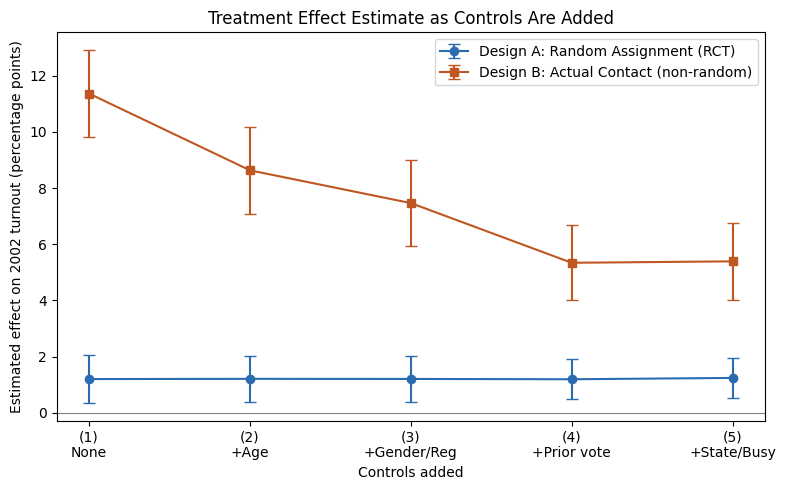

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
x = range(1, 6)
ax.errorbar(x, [c*100 for c in coef_A], yerr=[1.96*s*100 for s in se_A],
            marker='o', capsize=4, label='Design A: Random Assignment (RCT)', color='#2b6cb0')
ax.errorbar(x, [c*100 for c in coef_B], yerr=[1.96*s*100 for s in se_B],
            marker='s', capsize=4, label='Design B: Actual Contact (non-random)', color='#c05621')
ax.set_xticks(list(x))
ax.set_xticklabels(['(1)\nNone', '(2)\n+Age', '(3)\n+Gender/Reg', '(4)\n+Prior vote', '(5)\n+State/Busy'])
ax.set_xlabel('Controls added')
ax.set_ylabel('Estimated effect on 2002 turnout (percentage points)')
ax.set_title('Treatment Effect Estimate as Controls Are Added')
ax.axhline(0, color='gray', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig('rct_vs_selection.png', dpi=150)
plt.show()

## Takeaway

- **Random assignment (blue line):** the estimate is essentially flat around 1.2pp regardless of
  which controls are included. This stability is exactly the signature of a well-randomized
  experiment: since treatment is uncorrelated with everything else, controls have nothing to
  "soak up."
- **Non-random contact (orange line):** the estimate starts at 11pp and drops sharply once prior
  voting history is added, then levels off. The initial gap between 11pp and ~5pp isn't a real
  effect of the phone call, it's the fact that people who pick up the phone were already more
  civically engaged.
- The broader lesson: a regression can *correct* for observed differences between groups, but it
  can never fully substitute for randomization, because it can't correct for differences in
  things we didn't measure (e.g., underlying political interest). That's why the RCT estimate is
  more trustworthy than even a heavily-controlled observational estimate here.